In [2]:
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

In [37]:
def combine_dfs(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    r2_df = pd.concat([df[["name", "r2_test"]] for df in dfs])

    r2_df["group"] = r2_df["name"].str.extract(r"^(w_atom|no_added|w_bond|w_charge|full)")
    return r2_df

In [38]:
df_wo_atom = pd.read_csv(r"..\data\chemprop_results\1_chemprop_no_added_rerun_results.json")
df_wo_atom["name"] = "no_added"
df_wo_atom.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1.0,0.845441,0.153372,376,4,205,4,no_added
1,10,1.0,0.859221,0.142729,209,5,402,3,no_added
2,11,1.0,0.863927,0.135921,298,4,306,5,no_added
3,12,1.0,0.852326,0.151777,256,5,160,3,no_added
4,13,1.0,0.862279,0.134467,419,5,387,5,no_added


In [39]:
df_w_charge = pd.read_csv(r"..\data\chemprop_results\1_chemprop_no_added_w_charge_rerun_results.json")
df_w_charge["name"] = "w_charge"
df_w_charge.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1.0,0.853570,0.145305,329,5,392,3,w_charge
1,10,1.0,0.864841,0.137030,338,5,362,3,w_charge
2,11,1.0,0.859010,0.140832,157,5,412,3,w_charge
3,12,1.0,0.847881,0.156346,114,5,189,3,w_charge
4,13,1.0,0.832680,0.163367,298,5,432,2,w_charge


In [40]:
df_w_atom = pd.read_csv(r"..\data\chemprop_results\1_chemprop_atom_feat_rerun_results.json")
df_w_atom["name"] = "w_atom"
df_w_atom.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1.0,0.853236,0.145636,417,1,394,4,w_atom
1,10,1.0,0.854418,0.147598,148,1,223,5,w_atom
2,11,1.0,0.858636,0.141205,147,1,228,4,w_atom
3,12,1.0,0.856169,0.147827,340,3,220,4,w_atom
4,13,1.0,0.850406,0.146060,346,3,140,3,w_atom


In [41]:
df_w_bond = pd.read_csv(r"..\data\chemprop_results\1_chemprop_atom_bond_rerun_results.json")
df_w_bond["name"] = "w_bond"
df_w_bond.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1.0,0.851391,0.147467,162,2,159,3,w_bond
1,10,1.0,0.860615,0.141315,216,1,393,3,w_bond
2,11,1.0,0.860444,0.139400,175,1,180,4,w_bond
3,12,1.0,0.856573,0.147413,102,1,144,4,w_bond
4,13,1.0,0.867549,0.129322,156,1,246,4,w_bond


In [42]:
df_full = pd.read_csv(r"..\data\chemprop_results\1_chemprop_full_feat_rerun_results.json")
df_full["name"] = "full"
df_full.head()

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers,name
0,0,1.0,0.860169,0.138757,100,2,236,5,full
1,10,1.0,0.864261,0.137619,223,1,286,5,full
2,11,1.0,0.867435,0.132417,117,1,237,3,full
3,12,1.0,0.858450,0.145483,127,2,334,3,full
4,13,1.0,0.864684,0.132119,184,2,299,4,full


In [43]:
r2_df = combine_dfs([df_w_atom, df_wo_atom, df_w_charge, df_w_bond, df_full])
r2_df.head()

,name,r2_test,group
0,w_atom,0.853236,w_atom
1,w_atom,0.854418,w_atom
2,w_atom,0.858636,w_atom
3,w_atom,0.856169,w_atom
4,w_atom,0.850406,w_atom


In [44]:
summary = r2_df.groupby("group")["r2_test"].agg(["mean", "std"]).reset_index()

display(summary)

,group,mean,std
0,full,0.858962,0.008402
1,no_added,0.856062,0.009927
2,w_atom,0.854503,0.004753
3,w_bond,0.853407,0.008251
4,w_charge,0.853567,0.013201


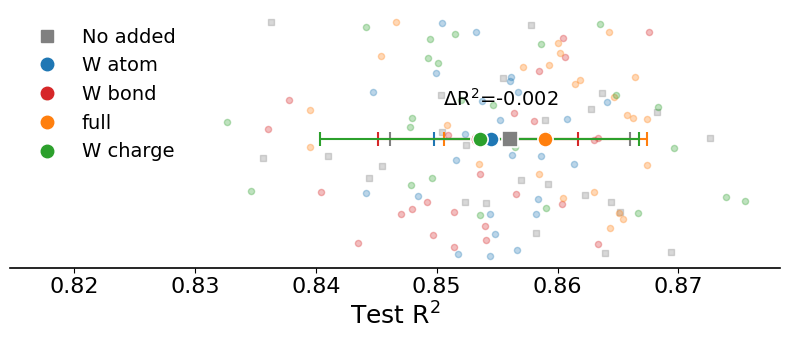

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

variants = ["no_added", "w_atom", "w_bond", "full", "w_charge"]
colors   = {"no_added": "grey", "w_atom": "tab:blue", "w_bond": "tab:red", "full": "tab:orange", "w_charge": "tab:green"}
markers  = {"no_added": "s",    "w_atom": "o", "w_bond": "o", "full": "o", "w_charge": "o"}
labels   = {"no_added": "No added", "w_atom": "W atom", "w_bond": "W bond", "full": "full", "w_charge": "W charge"}

fig, ax = plt.subplots(figsize=(8,3.5))

y = 0  # single row
jitter = 0.08

means = {v: summary.loc[summary["group"] == v, "mean"].values[0] for v in variants}

# Connecting line (dumbbell bar)
ax.plot([means["no_added"], means["w_atom"]], [y, y],
        color="lightgrey", linewidth=2, zorder=1)

# Delta label
delta = means["w_atom"] - means["no_added"]
mid_x = (means["no_added"] + means["w_atom"]) / 2
ax.text(mid_x, y + 0.02, r"$\Delta$R$^2$" + f"={delta:+.3f}",
        ha="center", va="bottom", fontsize=14)

for variant in variants:
    m = means[variant]
    s = summary.loc[summary["group"] == variant, "std"].values[0]

    subset = r2_df[r2_df["name"] == variant]["r2_test"].values
    jittered_y = y + np.random.uniform(-jitter, jitter, size=len(subset))

    ax.scatter(subset, jittered_y,
               color=colors[variant], marker=markers[variant],
               alpha=0.3, s=20, zorder=2)

    ax.scatter(m, y,
               color=colors[variant], marker=markers[variant],
               s=120, zorder=4, edgecolors="white", linewidths=1.2)

    ax.errorbar(m, y, xerr=s,
                fmt="none", color=colors[variant],
                capsize=5, capthick=1.5, linewidth=1.5, zorder=3)

# No y-axis ticks needed for a single row
ax.set_yticks([])
ax.tick_params(axis="x", labelsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.grid(False)

# Legend
handles = [
    mlines.Line2D([], [], color=colors[v], marker=markers[v],
                  linestyle="None", markersize=9, label=labels[v])
    for v in variants
]
ax.legend(handles=handles, frameon=False, loc="upper left", fontsize=14)

ax.set_xlabel(r"Test R$^2$", fontsize=18)

plt.tight_layout()